# Gardner Data: Path Lifting & Analysis

This notebook demonstrates the full pipeline on real Gardner et al. grid cell data:
1. Load spike data and position from the Gardner dataset
2. Extract toroidal coordinates and apply path lifting
3. Align recovered trajectory to ground-truth position
4. Compute overall mismatch score
5. Compute segmental mismatch scores

In [ ]:
import os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


# Ensure repo-root imports work no matter where the notebook kernel starts.
repo_root = Path.cwd()
if not (repo_root / "constants.py").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

sys.path.append('.')



from constants import GARDNER_DATA_PATH
from Gardner_data_test.Gardner_utils import get_spikes
from Gardner_data_test.Gardner_lifting_test import interpolate_2d_along_axis_0
from toroidal_coordinates.Gardner_toroidal import Gardner_coord
from toroidal_coordinates.compute_coord import interp_arr
from pipelines import (
    recover_traj_pipeline,
    compare_lifted_pipeline,
    segmental_compare_pipeline,
    plot_trajectory_comparison,
)

## 1. Load Gardner Data

Using rat R, module 1, open field session, day 2 — the standard example session.

In [2]:
RAT_NAME  = 'R'
MOD_NAME  = '1'
SESS_NAME = 'OF'
DAY_NAME  = 'day2'

sspikes, xx, yy, _, _ = get_spikes(
    RAT_NAME, MOD_NAME, DAY_NAME, SESS_NAME,
    bType='pure', bSmooth=True, bSpeed=True,
    folder=GARDNER_DATA_PATH,
)
original_coord = np.column_stack((xx, yy))

print(f"Spike matrix shape: {sspikes.shape}  (n_timesteps x n_cells)")
print(f"Position arrays: xx={xx.shape}, yy={yy.shape}")

Spike matrix shape: (126728, 111)  (n_timesteps x n_cells)
Position arrays: xx=(126728,), yy=(126728,)


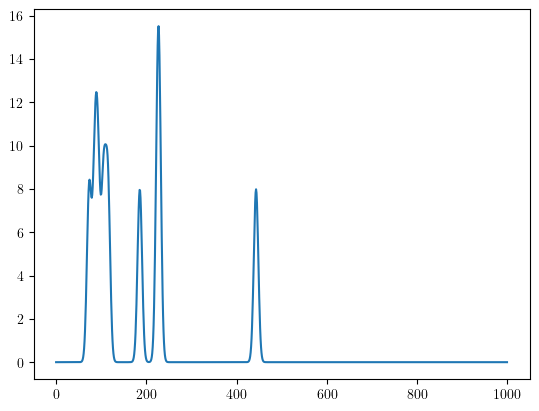

In [7]:
plt.plot(sspikes[:1000, 0])
plt.show()

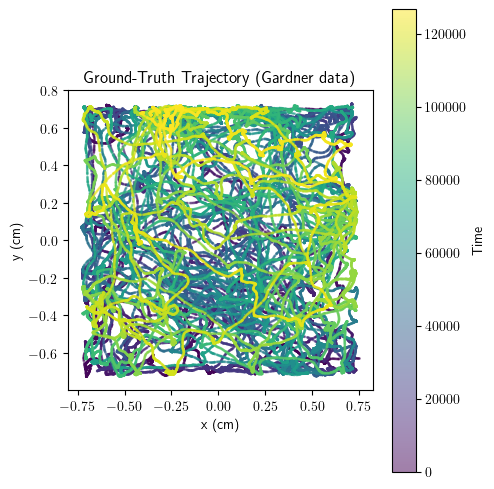

In [6]:
# Visualize the animal's ground-truth trajectory
fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(xx, yy, c=np.arange(len(xx)), cmap='viridis', s=1, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Time')
ax.set_title('Ground-Truth Trajectory (Gardner data)')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 2. Extract Toroidal Coordinates & Apply Path Lifting

In [7]:
# recover_traj_pipeline expects activity in shape (n_cells, n_timesteps)
tor_coord, lifted_coord = recover_traj_pipeline(sspikes.T)

lifted_coord_smooth = lifted_coord.copy()
lifted_coord_smooth[:, 0] = gaussian_filter1d(lifted_coord[:, 0], 10)
lifted_coord_smooth[:, 1] = gaussian_filter1d(lifted_coord[:, 1], 10)

print(f"Toroidal coord shape: {tor_coord.shape}")
print(f"Lifted coord shape:   {lifted_coord.shape}")

dreimac failed, falling back to gardner


/home/hyoon/GridCellDecoding/toroidal_coordinates/Gardner_toroidal.py:148: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


Toroidal coord shape: (126728, 2)
Lifted coord shape:   (126728, 2)


In [8]:
# TO REMOVE LATER
# check. We want 2pi - delta to be close to epsilon
from toroidal_coordinates.epsilon import compute_epsilon, compute_delta

delta = compute_delta(tor_coord)
epsilon = compute_epsilon(tor_coord)

print("delta:", delta)
print("2 pi - delta:", 2 * np.pi - delta)
print("epsilon:", epsilon)

delta: 4.779335962268521
2 pi - delta: 1.5038493449110648
epsilon: 1.5186296604861926


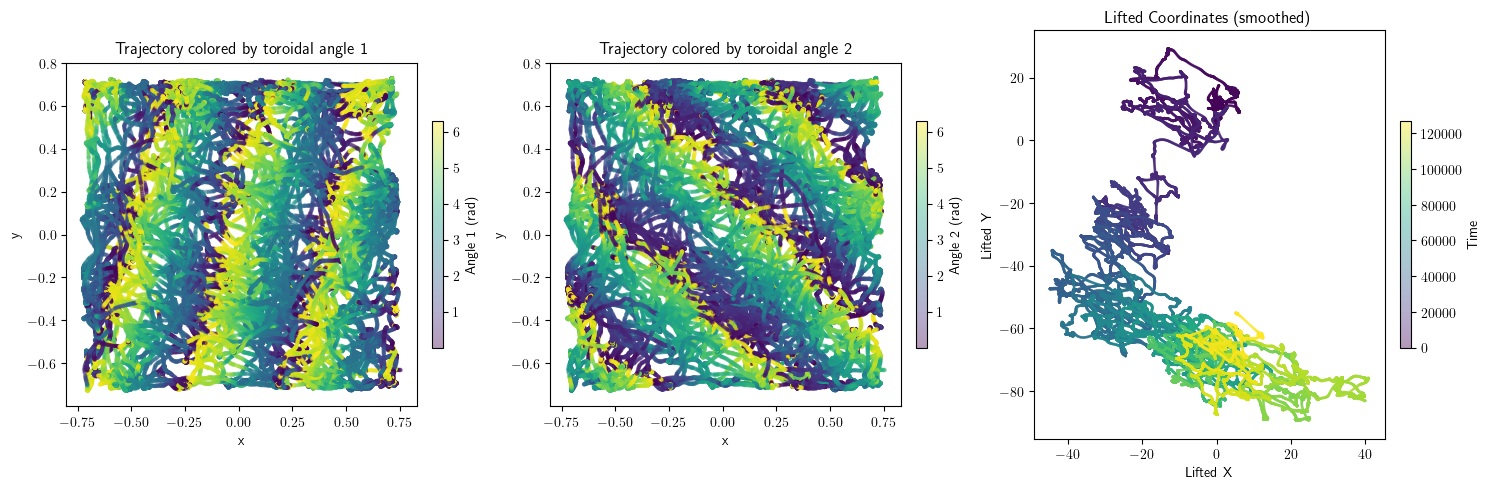

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Trajectory colored by toroidal angle 1
sc1 = axes[0].scatter(xx, yy, c=tor_coord[:, 0], cmap='viridis', s=5, alpha=0.4)
axes[0].set_title('Trajectory colored by toroidal angle 1')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_aspect('equal')
plt.colorbar(sc1, ax=axes[0], label='Angle 1 (rad)', fraction=0.03, pad=0.04)

# Trajectory colored by toroidal angle 2
sc2 = axes[1].scatter(xx, yy, c=tor_coord[:, 1], cmap='viridis', s=5, alpha=0.4)
axes[1].set_title('Trajectory colored by toroidal angle 2')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_aspect('equal')
plt.colorbar(sc2, ax=axes[1], label='Angle 2 (rad)', fraction=0.03, pad=0.04)

# Lifted coordinates
sc3 = axes[2].scatter(lifted_coord_smooth[:, 0], lifted_coord_smooth[:, 1],
                      c=np.arange(len(lifted_coord_smooth)), cmap='viridis', s=1, alpha=0.4)
axes[2].set_title('Lifted Coordinates (smoothed)')
axes[2].set_xlabel('Lifted X'); axes[2].set_ylabel('Lifted Y')
plt.colorbar(sc3, ax=axes[2], label='Time', fraction=0.03, pad=0.04)

plt.tight_layout()
plt.show()

## 3. Overall Mismatch Score

In [10]:
lifted_coord_transformed, overall_score = compare_lifted_pipeline(lifted_coord_smooth, original_coord)
print(f"Overall mismatch score: {overall_score:.6f}")

Mismatch score: 0.374883825311223
Overall mismatch score: 0.374884


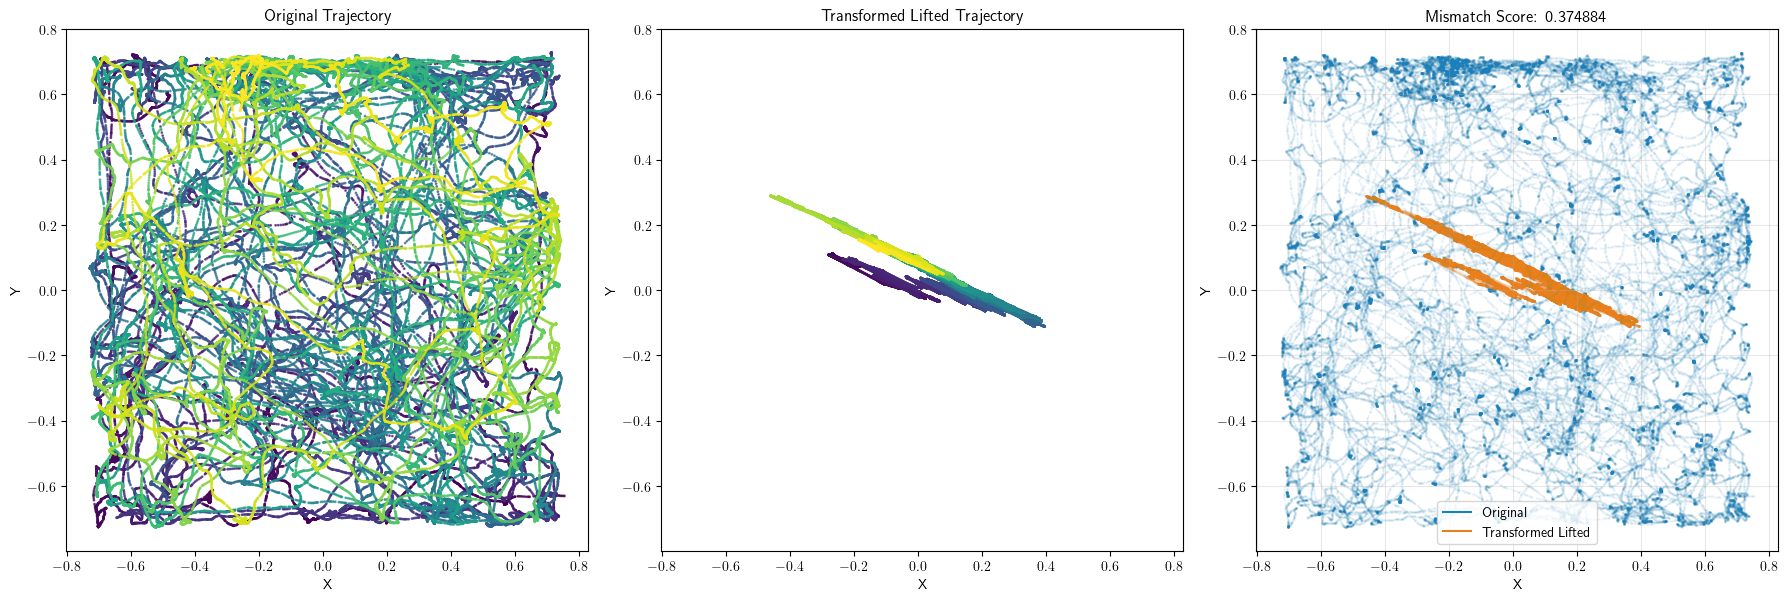

In [11]:
plot_trajectory_comparison(original_coord, lifted_coord_transformed, overall_score)

## 4. Segmental Mismatch Scores

Segment length: 2000 timepoints
Segmental mismatch scores: mean=0.094696, std=0.050898


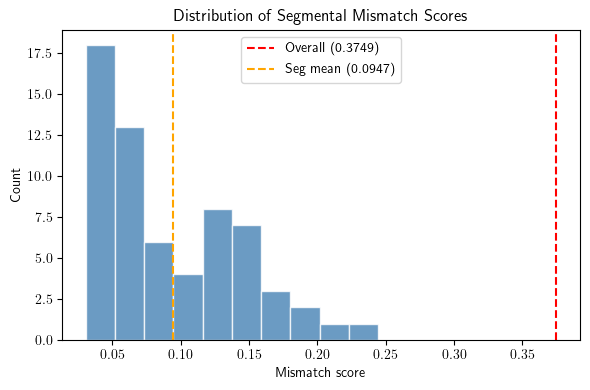


Summary:
  Overall mismatch:          0.374884
  Segmental mean ± std:      0.094696 ± 0.050898
  Segmental min / max:       0.030596 / 0.244414


In [12]:
# Segment length: ~10% of total trajectory
LEN_SEG = 2000
print(f"Segment length: {LEN_SEG} timepoints")

seg_scores = segmental_compare_pipeline(lifted_coord_smooth, original_coord, LEN_SEG)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(seg_scores, bins=10, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(overall_score, color='red', linestyle='--', label=f'Overall ({overall_score:.4f})')
ax.axvline(np.mean(seg_scores), color='orange', linestyle='--', label=f'Seg mean ({np.mean(seg_scores):.4f})')
ax.set_xlabel('Mismatch score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Segmental Mismatch Scores')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Overall mismatch:          {overall_score:.6f}")
print(f"  Segmental mean ± std:      {np.mean(seg_scores):.6f} ± {np.std(seg_scores):.6f}")
print(f"  Segmental min / max:       {np.min(seg_scores):.6f} / {np.max(seg_scores):.6f}")

IndexError: list index out of range

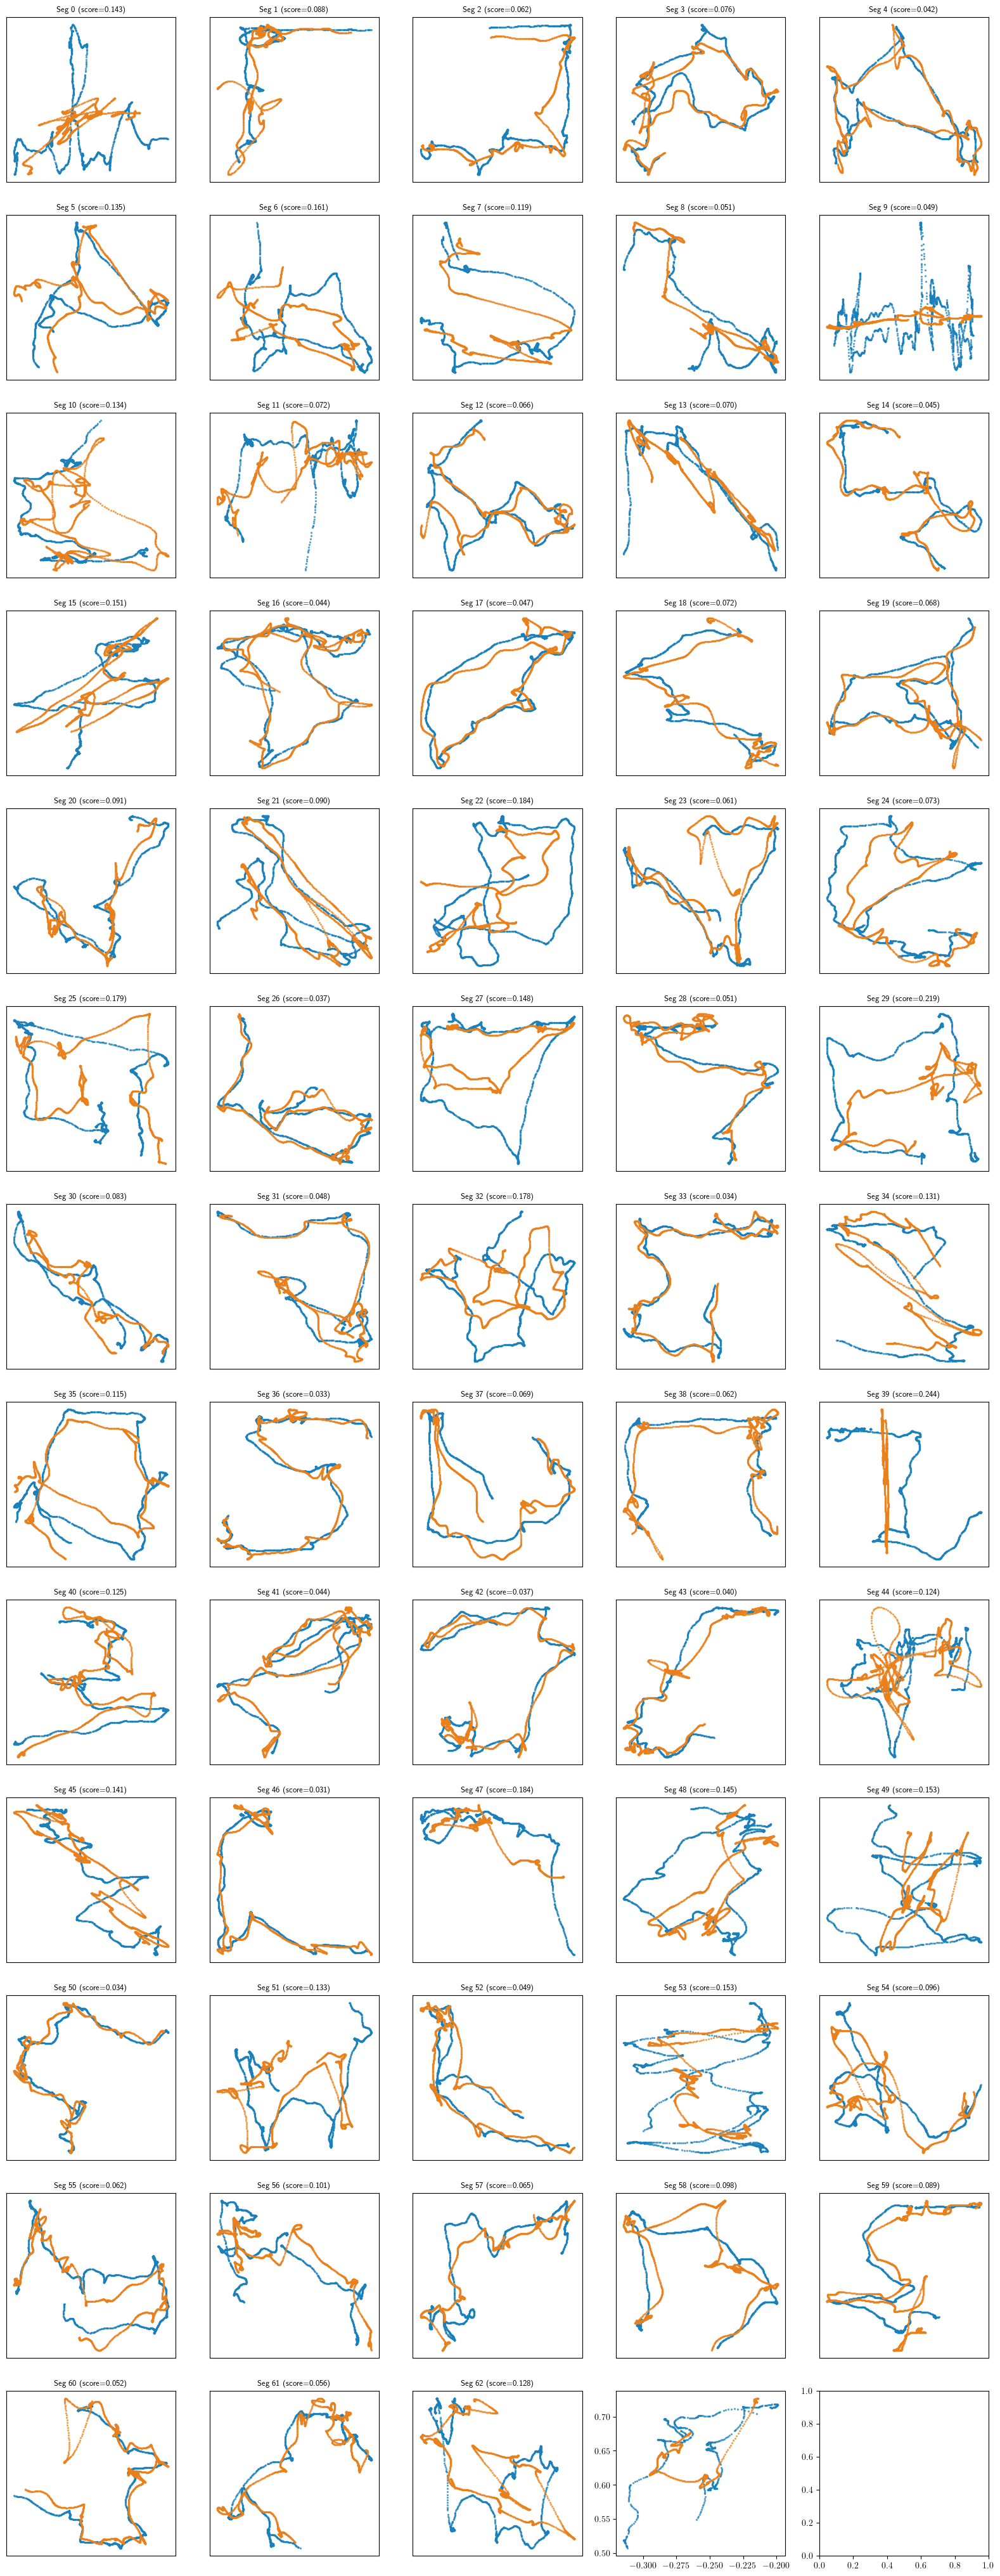

In [13]:
from affine_transform.get_transform_mat import get_transform_mat, apply_transform_mat

num_seg = len(lifted_coord_smooth) // LEN_SEG + 1
ncols = 5
nrows = (num_seg + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for i in range(num_seg):
    orig_seg = original_coord[i * LEN_SEG:(i + 1) * LEN_SEG]
    lift_seg = lifted_coord_smooth[i * LEN_SEG:(i + 1) * LEN_SEG]

    transform_mat = get_transform_mat(lift_seg, orig_seg)
    lift_seg_transformed = apply_transform_mat(lift_seg, transform_mat)

    ax = axes[i]
    ax.scatter(orig_seg[:, 0], orig_seg[:, 1], s=2, alpha=0.6, color='#1a80bb', label='Original')
    ax.scatter(lift_seg_transformed[:, 0], lift_seg_transformed[:, 1], s=2, alpha=0.6, color='#ea801c', label='Lifted')
    ax.set_title(f'Seg {i}  (score={seg_scores[i]:.3f})', fontsize=9)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Hide unused axes
for j in range(num_seg, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', markerscale=4, fontsize=10)

plt.suptitle('Original vs Lifted Trajectory — All Segments', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Overall mismatch:          {overall_score:.6f}")
print(f"  Segmental mean ± std:      {np.mean(seg_scores):.6f} ± {np.std(seg_scores):.6f}")
print(f"  Segmental min / max:       {np.min(seg_scores):.6f} / {np.max(seg_scores):.6f}")